# Mandatory Assignment: Quality classification of Vino Verde wines

###Domain description

According to Wikipedia (https://en.wikipedia.org/wiki/Vinho_Verde):

*Vinho Verde  refers to Portuguese wine that originated in the historic Minho province in the far north of the country.*

You are now going to devolop a model that can classify such wines from a set of features. We are interested in high quality wines. So such wines labelled as `True` ('high quality') or `False` ('not so high quality'). In our case `True` and `False` are the positive label and the negative label, respectively.



### Confusion Matrix and performance measures


Now take your time to recall the confusion matrix and classification and some important related performance measures

That is taking a look again on this in chapter 3 section regarding 'Confusion Matrices'

Especially keep in mind the following performance concepts related to classification:
*   **Precision** Fraction of positively predicted instances, that are correcly classified
*   **Recall** Fraction of postive labelled instances, that classified as positive
*   **Accuracy** Fraction of instances - positive or negative labbelled - that are coorectly classified.


Look at the toy example code below for clarification


Check also the following references:
1.   Calculating matrices: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
2.   Displaying confusion matrices: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

1.   Performance measures: https://scikit-learn.org/stable/modules/model_evaluation.html













In [29]:
highQLabels=[False,True]

In [30]:
import pandas as pd
from sklearn.metrics import confusion_matrix


y_true = [True, False, True, True, False, True, True, False, True, True, False, True, False, False, False, True, True, False, True, True]


y_pred = [False, False, True, True, False, True,False, False, True, True, False, True, True, False, False, True, True, False, True, False]


cm=confusion_matrix(y_true, y_pred, labels=highQLabels)
cm


array([[7, 1],
       [3, 9]])

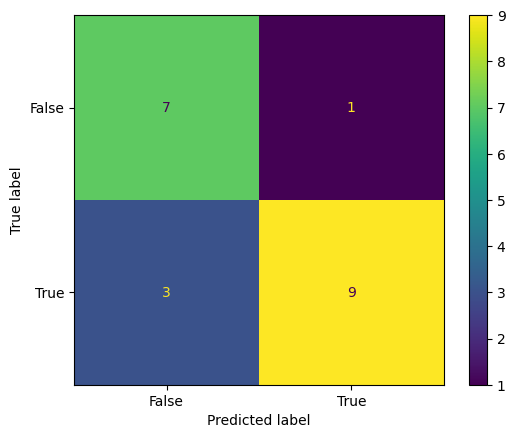

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(cm, display_labels=highQLabels)
disp.plot()
plt.show()

In [32]:

from sklearn.metrics import precision_score
precision_score(y_true, y_pred)

0.9

In [33]:

from sklearn.metrics import recall_score
recall_score(y_true, y_pred)

0.75

In [34]:

from sklearn.metrics import accuracy_score
accuracy_score(y_true, y_pred)

0.8

### Assignment 1: What does the performance measures mean?

Explain how the precission, recall and accuracy performance measures can make sense ?

What does that mean in our Portuguese wine case ?

Add text cells below for your answer.

Accuracy:
(TP + TN) / (TP + TN + FP + FN). Acuraccy kan gøre, at der bliver gjort en lille misforståelse i den korrekte balance af den høje og lave kvalitet. Hvis datasættet er ubalanceret, så vil der være en skævhed i preciseringen af vinene. men ellers vil denne model være gavnlig hvis man kun sælger vinene, da man vil kunne undgå falske positiver.

Recall:
Af alle vinene, så er det recall som er fraction som identificerer dem af højere kvalitet recall = TP / (TP + FN). Dette er brugbart og mere sikkert mht. at finde en vin som er af højere kvalitet. Den er mere præcis.

Precision:
Her forsøger at at forudsige hvilke vine som har den højeste kvalitet. precision = TP / (TP + FP). Dette er brugbart, hvis man sælger vinen som high-quality.

### Assignment 2: Importing data

Do the following:
1.   Please find the wines quality here:  
https://raw.githubusercontent.com/jpandersen61/Machine-Learning/refs/heads/main/WineQT.csv
2.   Run the next cell below to load the data in.


In [35]:
datafile="https://raw.githubusercontent.com/jpandersen61/Machine-Learning/refs/heads/main/WineQT.csv"
dataset = pd.read_csv(datafile)
dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


###Assignment 3: Checking the dataset

Always do yourself a favour to check data:
1.   Extract information about the data structure with the `type` method in a cell code cell below.
2.   Check dataset with `info()` method provided by the `DataFrame` class in a cell code cell below.
3.   Is there any missing data in the dataset?
4.   State your observations on the dataset in a text cell below





In [36]:
print(type(dataset))
dataset.info()


dataset.describe()


dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


State your observations on the dataset:
Dataset is of type DataFrame and there no missing values

Der er på hverken dataset.info(), dataset.describe() eller dataset.isnull().sum() nogen former for udfald på datasættet.

### Assignment 4: Selecting features and labels

Introduce code in the cells below that do the following:
1.   You may drop some features. E.g. with `dataset.drop(..., axis=1, inplace=True)`. Consider dropping some of the 'acidity' and 'sulfur' features, because the may depend on similar features.
2.   Extract the features with `X = dataset.iloc...`. Remember to leave out 'quality' and 'Id'
1.   Extract the quality class labels with `y = dataset["quality"].isin([6,7])` This will assign 'high quality' (`True` value) to wines having quality 6 or 7. The rest of the wines will then have their quality class labelled with `False`

Introduce one or more cells to carry what is mentioned above.

If time allows: you may also try experient with combining features






Introduce code in the cell below that stratifies the dataset:
1.   Import the `train_test_split` stratifier - that is: `from sklearn.model_selection import train_test_split`
2.   Split the dataset in training set and test set, where we stratify on the quality class labels - that is: `X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)`  

Check also the following references on `train_test_split`:
1.   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
2.   Chapter 2 and Python code base for chapter: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html




In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Load dataset
datafile = "https://raw.githubusercontent.com/jpandersen61/Machine-Learning/refs/heads/main/WineQT.csv"
dataset = pd.read_csv(datafile)



dataset.head()


dataset.columns



y = dataset['quality'].isin([6, 7])



X = dataset.drop('quality', axis=1)



print(X.shape)
print(y.value_counts())
X.head()



(1143, 12)
quality
True     605
False    538
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4


In [21]:

X_train, X_test, y_train, y_test = train_test_split(
X, y, stratify=y, random_state=42, test_size=0.2
)


print('Training set class distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest set class distribution:')
print(y_test.value_counts(normalize=True))

Training set class distribution:
quality
True     0.52954
False    0.47046
Name: proportion, dtype: float64

Test set class distribution:
quality
True     0.528384
False    0.471616
Name: proportion, dtype: float64


### Assignment 5: Stratifying the dataset (continued)

Answer the following questions:
1.   What are the variables `X_train`, `X_test`, `y_train` and `y_test` going to be used for ?
2.   Explains the parameter `stratify=y` (Hint: Yes it has something to with stratifiction on quality class labels)

State your answers (e.g. in a cell below)


1:
X_train gør så alle objekter (syre, sukker, alkohol) for de vine, der bruges til at træne modellen.

y_train har (True/False) for træningsdataen. Dette er ift. om hver vin er af høj kvalitet.

X_test Har værdier som testen ikke før har set.

y_test Har de labels som er sande.


2:
stratify=y er med til at sikre så fordelingen af kvalitetsklasserne (True & false) er den samme i både trænings- og testdatasættet.

### Assignment 6: Establish the MLP Classifier and pipeline

Do the following in the cell below to establish a Multi Layer Perceptron:
1.   Import the classifier - that is: `from sklearn.neural_network import MLPClassifier`
2.   Import the standard scaler - that is: `from sklearn.preprocessing import StandardScaler`
1.   Import pipelining - that is: `from sklearn.pipeline import make_pipeline`
2.   Establish the MLP Classifier - that is something like this `MLPClassifier(hidden_layer_sizes=[5], activation="relu" , max_iter=10_000, random_state=42)`
1.   Establish a pipeline containing `MLPClassifier` and `StandardScaler`- that is something like this:  `make_pipeline(StandardScaler(), ...)`



Also check the following references:
1.   MLP Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html and Chapter 10 including code reference for this chapter: https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb
2.   Standard scaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html and chapter 2
1.   Pipelining: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html and  chapter 2






In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



mlp = MLPClassifier(hidden_layer_sizes=[5], activation='relu', max_iter=10_000, random_state=42)


pipeline = make_pipeline(StandardScaler(), mlp)


pipeline

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[5], max_iter=10000,
                               random_state=42))])

### Assignment 7: Establish the MLP Classifier and pipeline (continued)

Answer the following questions (e.g. in a cell below):
1.   Why is it important to apply the `StandardScaler` ?
2.   What is the point on establishing a pipeline ?
1.   Explain the `hidden_layer_sizes` parameter.
2.   Explain the `activation` paramater.
1.   Explain the `max_iter` parameter.       
2.   Explain the `random_state` parameter.
1.   Can you find out how many layers perceptron has (hint: look after an attribute) ?










Why is it important to apply the StandardScaler ?
Fordi enheden er målt på flere forskellige skalaer.

What is the point on establishing a pipeline ?
En pipeline sørger for at både skalering og processering sker konstant under datasætstræning. Dette er med til at sikre datatab.

Explain the hidden_layer_sizes parameter.
Den opsætter arkitekturen af det neurale netværk.

Explain the activation paramater.
Bestemmer hvilken aktiv funktion der skal bruges i det neurale netværk. F.eks. "relu" som ofte er brugt i dybere netværk.

Explain the max_iter parameter.
Sætter det maksimale antal trænings perioder som MLP'en vil stoppe når maks er nået.

Explain the random_state parameter.
Kontrollerer det tilfædlige indlæsning af netværkets data.

Can you find out how many layers perceptron has (hint: look after an attribute) ? Der burde være 3 lag, men et skjult lag på 1. Og ellers er der en attribut på 5.


### Assignment 8: Fitting the model

Fit the model by calling the `fit` method on the pipeline in the cell below


In [13]:
# Fit modellen på træningsdata
pipeline.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[5], max_iter=10000,
                               random_state=42))])

### Assignment 9: Fitting the model (continued)

Answer the following question(s) (e.g. in a cell below):
1.   What does it actually mean to fit a model ?
1.   What does specifically mean in our wine case model ?







What does it actually mean to fit a model ?¨
Dette betyder i virkeligheden at man træner den. Den lærer de sammenhænge der er mellem inputs og outputs labels.
Under træningen, justeres de vægte og biases af MLP'en.

What does specifically mean in our wine case model ?
I vores vin-tilfælde, har vi med vin-egenskaber at gøre som fortæller hvilken kvalitet vinen har, og derfor er det sådan, at modellen lærer noget om de egenskaber som f.eks. alkohol og sukkerindhold. Og så er der høj kvalitet og lav kvalitet (true or false).

### Assignment 10: Observing the models score

Do the following in the cells below to calculate the models accuracy score:
1.   Calculate the accuracy score on the training set - that is: `pipeline.score(X_train, y_train)` in its own cell
2.   Calculate the accuracy score on the test set - that is: `pipeline.score(X_test, y_test)` in its own cell

Also Check the following references on pipelining:
1.   Score method: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.score


In [17]:
train_score = pipeline.score(X_train, y_train)
print("Træningsnøjagtighed:", train_score)

test_score = pipeline.score(X_test, y_test)
print("Testnøjagtighed:", test_score)


Træningsnøjagtighed: 0.7461706783369803
Testnøjagtighed: 0.7685589519650655


Som man kan se er der en træningsnøjagtihed som er rimelig. De har ca. den samme nøjagtighed.

### Assignment 11: Observing the models score (continued)





Observe among other things on the underfit and overfit conditions:
1.   Try different settings of `hidden_layer_sizes` and  `activation` parameters
2.   Try dropping out and/or combine features
1.   What do you observe?

State your answers and observations (e.g. in a cell below)





In [19]:
for hidden in ([5], [10], [10, 5], [20, 10, 5]):
    mlp_test = MLPClassifier(hidden_layer_sizes=hidden, activation='relu', max_iter=10_000, random_state=42)
    pipe_test = make_pipeline(StandardScaler(), mlp_test)
    pipe_test.fit(X_train, y_train)
    print(f"hidden_layer_sizes={hidden}")
    print("  Training accuracy:", pipe_test.score(X_train, y_train))
    print("  Test accuracy:", pipe_test.score(X_test, y_test))
    print()


hidden_layer_sizes=[5]
  Training accuracy: 0.7461706783369803
  Test accuracy: 0.7685589519650655

hidden_layer_sizes=[10]
  Training accuracy: 0.7800875273522976
  Test accuracy: 0.777292576419214

hidden_layer_sizes=[10, 5]
  Training accuracy: 0.8107221006564551
  Test accuracy: 0.7510917030567685

hidden_layer_sizes=[20, 10, 5]
  Training accuracy: 0.9704595185995624
  Test accuracy: 0.7685589519650655



Som man kan se bruger vi "relu", og vi får en række forskellige tests. Man kan se at testnøjagtigheden stiger og derefter falder en smule, så måske der er en smule tegn på at sættene er overfitted. Den bedste balance mellem træninger og tests ser ud til at være når hidden_layer_sizes=[10] da den præsterer ca. ens med 0.78 og 0.77

### Assignment 12: Confusion Matrix and performance measures (revisited)



Repeat assignment 1 with MLP Classifiers' score fitted with the Vino Verde wines dataset

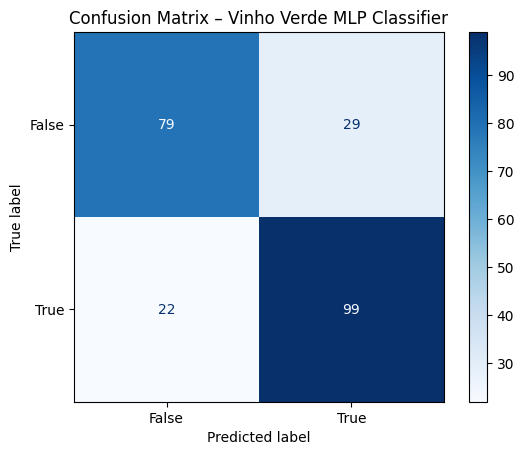

Precision: 0.773
Recall: 0.818
Accuracy: 0.777


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt


best_mlp = MLPClassifier(hidden_layer_sizes=[10], activation='relu', max_iter=10_000, random_state=42)
best_pipeline = make_pipeline(StandardScaler(), best_mlp)
best_pipeline.fit(X_train, y_train)


y_pred = best_pipeline.predict(X_test)


cm = confusion_matrix(y_test, y_pred, labels=[False, True])
disp = ConfusionMatrixDisplay(cm, display_labels=[False, True])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Vinho Verde MLP Classifier")
plt.show()


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Accuracy: {accuracy:.3f}")


Fortolkning af resultaterne af assignment 12:

Confusion matrix viser os hvor mange vine der e rblevet klassiificeret som gode og dårlige.

recall:
Viser andelen af de reele kvalitetsvine

Accuracy:
Viser den samlede andel af korrekt klassificeret vine.

Vi får alt i alt et resultat som viser at MLP-modellen præsterer balanceret. Der er ikke noget der stikker af, tallene 0.77, 0.81 & 0.77 er ikke langt fra hinanden.

### Assignment 13:Try with other classifiers - Extra

For the fast ones

Try to get a better a performance by applying another classifier algorithm